# Goal

To see how different optimization algorithms update weights of a model. The algorithms used will be:
1. Batch Gradient descent
2. Mini-batch gradient descent
3. Gradient with momentum (with mini-batch)
4. RMSprop (with mini-batch)
5. Adam optimizier (with mini-batch)

My theory is that first algorithm will be slow but the updates will have medium amount of noise. Second algorithm will be noiser but faster. The third should have low noise and be as fast as second, fourth should have roughly as much noise as third and be as fast while the last should have least noise and be as fast as second

In [120]:
# Imports
import numpy as np
import numpy.typing as npt
import time
import math
import matplotlib.pyplot as plt
rng = np.random.default_rng(121)


## Preparations

The code below creates a synthetic dataset that I will use to visualize the optimizations. It will also have implementations for forward prop, backprop, cost function and gradient check to confirm implementation of backprop. It will also have functions for displaying the contour and 3D plots

In [121]:
# Generate synthetic data
synthetic_w_1 = rng.random() * 100
synthetic_w_2 = rng.random() * 100

m = 512
n = 2

# Constants for different training algorithms
num_epochs = 100
batch_size = 128
num_epochs_batched = 25
alpha=0.3

synthetic_w = np.array([[synthetic_w_1, synthetic_w_2]])
noise = rng.random(m) * 0.1
X = rng.random((n, m)) * 100
Y = np.matmul(synthetic_w, X) + noise

mean = np.mean(X)
std = np.std(X)
std = np.where(std == 0, 1.0, std)

X_normalized = (X - mean) / std


In [122]:
def f_x(
    X: npt.NDArray,
    w: npt.NDArray,
): 
    """ 
    Function for getting prediction from model
    
    Args:
        X (ndarray) : a (2, m) array with m training examples
        w (ndarray) : a (1, 2) array with weights for making prediction
        
    Returns:
        Y_pred (ndarray): a (1,m) array with the models predictions
        Z (ndarray): cached Z value
    """
    Z = np.matmul(w, X)
    A = np.maximum(0, Z)
    return (A, Z)

In [123]:
def J(
    X: npt.NDArray,
    Y: npt.NDArray,
    w: npt.NDArray,
):
    """ 
    Function to get cost of parameters in the dataset
    
    Args:
        X (ndarray): a (2, m) array with m training examples
        Y (ndarray): a (1, m) array with target outputs
        w (ndarray): a (1, 2) array with weights
        
    Returns:
        cost (scalar): cost of weights for dataset
    """
    m = X.shape[1]
    Y_pred, _ = f_x(X=X, w=w)
    
    return np.sum((Y_pred - Y) ** 2) / (2 * m)
    

In [124]:
def backprop(
    X: npt.NDArray,
    Y: npt.NDArray,
    w: npt.NDArray,
):
    """ 
    Returns derivatives of the weights and bias
    
    Args:
        X (ndarray): a (2, m) array with m training examples
        Y (ndarray): a (1, m) array with m target outputs
        w (ndarray): a (1,2) array with weights of the model
        
    Returns:
        dw (ndarray): a (1,2) array with derivatives of the weights of the model
    """
    m = X.shape[1]
    Y_pred, Z = f_x(X=X, w=w)
    dA = Y_pred - Y
    dZ = np.where(Z < 0, 0, dA)
    dw = np.matmul(dZ, X.T) / m
    
    return dw

In [125]:
# Confirming backprop implementation
def grad_check(
    X: npt.NDArray,
    Y: npt.NDArray,
    w: npt.NDArray,
):
    """ 
    Checks whether derivatives returned from backprop and approximated derivatives are close enough
    
    Args:
        X (ndarray): a (2, m) array with m training examples
        Y (ndarray): a (1, m) array with m target outputs
        w (ndarray): a (1,2) array with weights of the model
        
    Returns:
        similarity (scalar): measure of how close calculated and approximate derivatives are
        dtheta (ndarray): concatenated calculated derivatives
        dtheta_approx (ndarray): concatenated approximated derivatives
    """
    num_params = 2
    
    dw = backprop(X=X, Y=Y, w=w)
    theta = np.array([w[0][0], w[0][1]])
    dtheta = np.array([dw[0][0], dw[0][1]])
    dtheta_approx = np.zeros((num_params,))
    
    epsilon = 1e-7
    
    for i in range(num_params):
        theta_right = theta.copy()
        theta_right[i] += epsilon
        theta_left = theta.copy()
        theta_left[i] -= epsilon
        J_theta_right = J(X=X, Y=Y, w=np.array([[theta_right[0], theta_right[1]]]))
        J_theta_left = J(X=X, Y=Y, w=np.array([[theta_left[0], theta_left[1]]]))
        
        dtheta_approx[i] = (J_theta_right - J_theta_left) / (2 * epsilon)
        
    difference = np.linalg.norm(dtheta_approx - dtheta)
    similarity = difference / (np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta))
    return (similarity, dtheta, dtheta_approx)

In [126]:
initial_w = rng.random((1, 2))
similarity, dtheta, dtheta_approx = grad_check(X=X_normalized, Y=Y, w=initial_w)

print(f"Similarity between dtheta and dtheta approx is: {similarity}")
print(dtheta)
print(dtheta_approx)

assert similarity <= 1e-6 # If it fails this it is a bad implementation of backprop

Similarity between dtheta and dtheta approx is: 9.019495478118521e-07
[-1596.56125458 -2371.42555718]
[-1596.56628966 -2371.42667174]


In [127]:
# Get different costs for our problem
w1_values = np.linspace(0, 10000, 1000)
w2_values = np.linspace(0, 10000, 1000)

W1, W2 = np.meshgrid(w1_values, w2_values)
Z = np.zeros_like(W1)

# Get costs for each point
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        
        w = np.array([[
            W1[i, j],
            W2[i, j]
        ]])
        
        Z[i,j] = J(X=X_normalized, Y=Y, w=w)
    

In [128]:
def plot_optimization_trajectory(
    w1_history,
    w2_history,
    costs,
    optimization_algorithm
):
    dx = np.diff(w1_history)
    dy = np.diff(w2_history)
    
    plt.figure(figsize=(16, 7))

    # Contour plot

    # Contours
    contours = plt.contour(
        W1,
        W2,
        Z,
        levels=100
    )

    # Label contour lines
    plt.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt='%.0e'
    )

    N = len(dx)
    plt.quiver(
        w1_history[:-1],
        w2_history[:-1],
        dx,
        dy,
        np.arange(N),
        cmap='plasma',
        angles='xy',
        scale_units='xy',
        scale=1,
        width=0.003
    )
    plt.colorbar(label="Iteration")
    
    plt.scatter(
        w1_history[0],
        w2_history[0],
        s=100,
        marker='s',
        label='Start'
    )

    # End
    plt.scatter(
        w1_history[-1],
        w2_history[-1],
        s=100,
        marker='*',
        label='End'
    )

    plt.legend()

    plt.title(f"Contour Plot for optimization of {optimization_algorithm}")
    plt.xlabel("w1")
    plt.ylabel("w2")

    plt.tight_layout()
    plt.show()

## Batch Gradient Descent

Cost at epoch 1 / 100: 10989365.228849117
Cost at epoch 2 / 100: 9260423.417915855
Cost at epoch 3 / 100: 8018326.871877179
Cost at epoch 4 / 100: 7134224.447641192
Cost at epoch 5 / 100: 6501455.016852594
Cost at epoch 6 / 100: 6033957.149139781
Cost at epoch 7 / 100: 5682919.272148348
Cost at epoch 8 / 100: 5412987.722351435
Cost at epoch 9 / 100: 5190162.091127837
Cost at epoch 10 / 100: 5005052.4346902985
Cost at epoch 11 / 100: 4860174.54804285
Cost at epoch 12 / 100: 4744879.03386387
Cost at epoch 13 / 100: 4644726.521045909
Cost at epoch 14 / 100: 4550960.250497218
Cost at epoch 15 / 100: 4459494.4665383985
Cost at epoch 16 / 100: 4377535.023813818
Cost at epoch 17 / 100: 4302974.198656799
Cost at epoch 18 / 100: 4230527.141205202
Cost at epoch 19 / 100: 4171467.735039018
Cost at epoch 20 / 100: 4122642.340275276
Cost at epoch 21 / 100: 4076749.3004195527
Cost at epoch 22 / 100: 4037566.1636704905
Cost at epoch 23 / 100: 4006741.320251596
Cost at epoch 24 / 100: 3978846.76661158

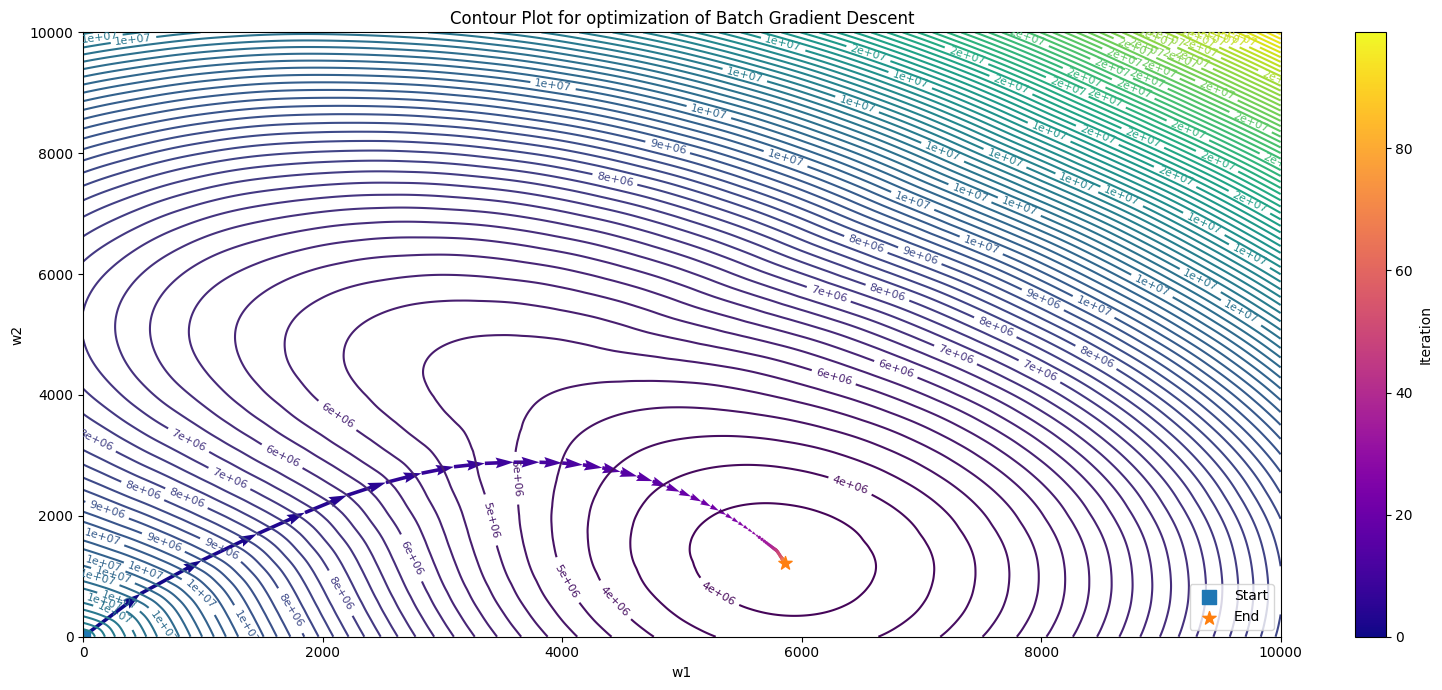

In [129]:
def batch_gradient_descent(
    X: npt.NDArray,
    Y: npt.NDArray,
    w: npt.NDArray,
    alpha: float,
    num_epochs: int
):
    """ 
    Algorithm to minimize the cost functions by updating parameters in every epoch
    
    Args:
        X (ndarray): a (2, m) array with m training examples
        Y (ndarray): a (1, m) array with target outputs
        w (ndarray): a (1,2) array with weights to optimize
        alpha (scalar): learning rate to be used by the model
        num_epochs (scalar): number of times to go through entire dataset
        
    Returns:
        w (ndarray): optimized weights
        w_s (ndarray): weights reached while performing gradient descent
        costs (ndarray): costs of the different weights reached by learning algorithm
    """
    # Get initial cost of weights
    w_s = [(w[0][0], w[0][1])]
    costs = [J(X=X, Y=Y, w=w)]
    
    # For each epoch
    for epoch in range(num_epochs):
        # get derivatives
        dw = backprop(X=X, Y=Y, w=w)
        
        # Update weights with derivatives
        w = w - (alpha * dw)
        
        # Store new weights and cost of weights
        cost = J(X=X, Y=Y, w=w)
        w_s.append((w[0][0], w[0][1]))
        costs.append(cost)
        print(f"Cost at epoch {epoch + 1} / {num_epochs}: {cost}")
        
    return (w, w_s, costs)

start_time = time.perf_counter()
updated_w, w_s, costs = batch_gradient_descent(X=X_normalized, Y=Y, w=initial_w, alpha=alpha, num_epochs=num_epochs)
stop_time = time.perf_counter()
elapsed_time = stop_time - start_time
print(f"Batch gradient descent took {elapsed_time:.6f}s")

w1_history = [w[0] for w in w_s]
w2_history = [w[1] for w in w_s]

plot_optimization_trajectory(w1_history=w1_history, w2_history=w2_history, costs=costs, optimization_algorithm="Batch Gradient Descent")

## Mini-batch Gradient Descent

Cost at batch 1 / 4 of epoch 1 / 25 = 11050308.775843106
Cost at batch 2 / 4 of epoch 1 / 25 = 8885775.815872706
Cost at batch 3 / 4 of epoch 1 / 25 = 8061239.741998194
Cost at batch 4 / 4 of epoch 1 / 25 = 7576498.77733049
Cost at batch 1 / 4 of epoch 2 / 25 = 6632049.247517396
Cost at batch 2 / 4 of epoch 2 / 25 = 6054905.764664685
Cost at batch 3 / 4 of epoch 2 / 25 = 5584590.915664909
Cost at batch 4 / 4 of epoch 2 / 25 = 5601212.807499731
Cost at batch 1 / 4 of epoch 3 / 25 = 5336013.606683837
Cost at batch 2 / 4 of epoch 3 / 25 = 5243469.830520064
Cost at batch 3 / 4 of epoch 3 / 25 = 4959697.842328063
Cost at batch 4 / 4 of epoch 3 / 25 = 4748341.364270162
Cost at batch 1 / 4 of epoch 4 / 25 = 4652158.179965132
Cost at batch 2 / 4 of epoch 4 / 25 = 4955743.710485879
Cost at batch 3 / 4 of epoch 4 / 25 = 4651091.008212054
Cost at batch 4 / 4 of epoch 4 / 25 = 4289010.385686565
Cost at batch 1 / 4 of epoch 5 / 25 = 4262687.75370408
Cost at batch 2 / 4 of epoch 5 / 25 = 4768976.240

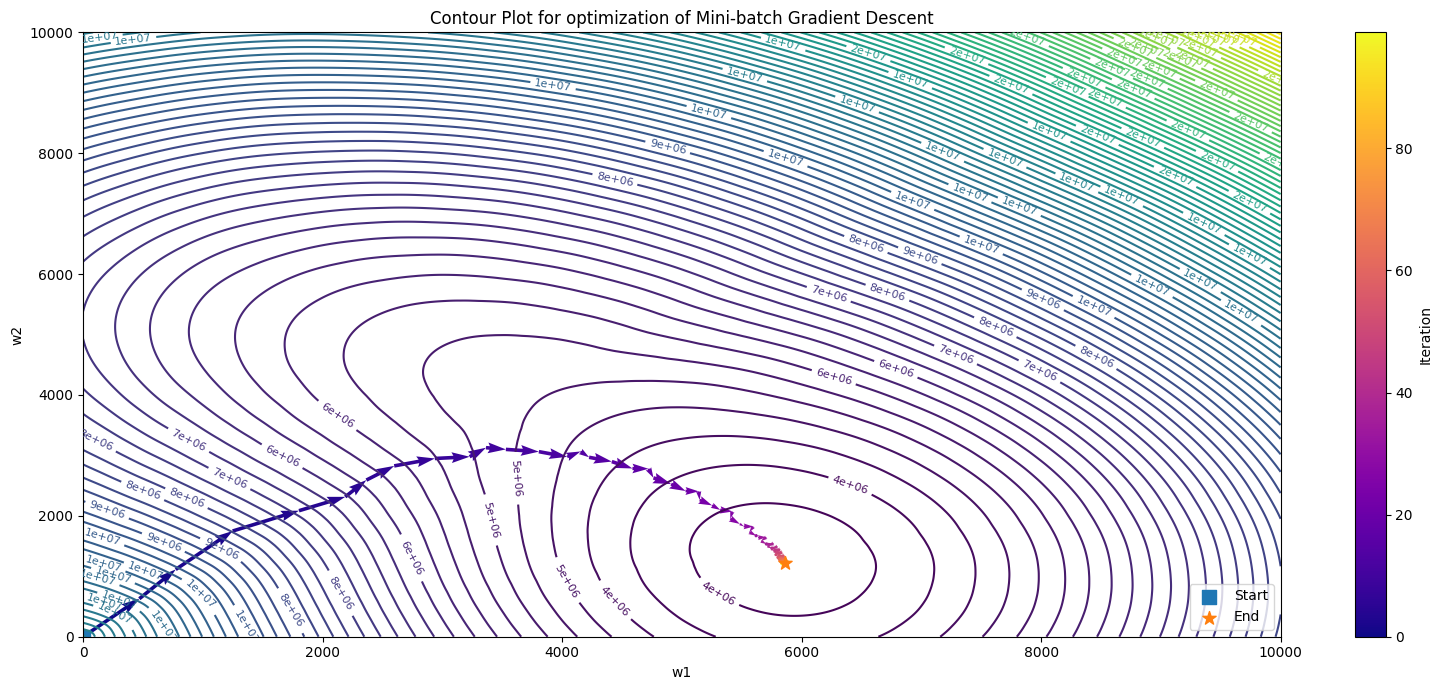

In [135]:
def mini_batch_gradient_descent(
    X: npt.NDArray,
    Y: npt.NDArray,
    w: npt.NDArray,
    alpha: float,
    batch_size: int,
    num_epochs: int
):
    """ 
    Runs mini-batch gradient descent for optimizing weights
    
    Args:
        X (ndarray): a (2, m) array with m training examples
        Y (ndarray): a (1, m) array with m target outputs
        w (ndarray): a (1, 2) array with weights
        alpha (scalar): learning rate for algorithm
        num_epochs (scalar): number of times to go through data set
        
    Returns:
        updated_w (ndarray): a (1,2) array with optimized weights
        w_s (ndarray): list of weights that model passed through
        costs (ndarray): list of costs for different weights model passed through
    """
    m = X.shape[1]
    num_batches = math.ceil(m / batch_size)
    
    # Store initial weights with their costs
    w_s = [(w[0][0], w[0][1])]
    costs = [J(X=X, Y=Y, w=w)] # Not sure if I should get cost of entire dataset
    
    # For each epoch
    for epoch in range(num_epochs):
        # For each batch
        for t in range(num_batches):
            # Get Xt, Yt
            if t == num_batches - 1:
                start = t * batch_size
                Xt = X[:, start:]
                Yt = Y[:, start:]
            else:
                start = t * batch_size
                end = start + batch_size
                Xt = X[:, start:end]
                Yt = Y[:, start:end]
                
            # Get derivatives with Xt, Yt
            dw = backprop(X=Xt, Y=Yt, w=w)
            
            # Update weights
            w = w - (alpha * dw)
            
            # Store new weights with their cost
            cost = J(X=Xt, Y=Yt, w=w)
            w_s.append((w[0][0], w[0][1]))
            costs.append(cost)
            
            print(f"Cost at batch {t + 1} / {num_batches} of epoch {epoch + 1} / {num_epochs} = {cost}")
            
    return (w, w_s, costs)
 
start_time = time.perf_counter()   
updated_w, w_s, costs = mini_batch_gradient_descent(X=X_normalized, Y=Y, w=initial_w, alpha=alpha, batch_size=batch_size, num_epochs=num_epochs_batched)
stop_time = time.perf_counter()
elapsed_time = stop_time - start_time
print(f"Mini-batch gradient descent took {elapsed_time:.6f}s")

w1_history = [w[0] for w in w_s]
w2_history = [w[1] for w in w_s]

plot_optimization_trajectory(w1_history=w1_history, w2_history=w2_history, costs=costs, optimization_algorithm="Mini-batch Gradient Descent")